# **EDA**

# **1. Setup**

Cell ini menyiapkan semua library yang dibutuhkan untuk proses EDA, imagehash untuk deteksi gambar mirip (di-install dulu karena tidak bawaan Colab), pandas/numpy untuk mengolah data dalam bentuk tabel, PIL dan cv2 (OpenCV) untuk membaca dan menganalisis gambar, matplotlib/seaborn untuk visualisasi, dan tqdm untuk menampilkan progress bar saat memproses ribuan gambar.

In [ ]:
!pip install -q imagehash

import os, zipfile, pathlib, hashlib, shutil
import numpy as np
from google.colab import files

uploaded = files.upload()  # pilih archive_1.zip
zip_path = list(uploaded.keys())[0]

extract_dir = '/content/corn_dataset'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

data_dir = pathlib.Path(extract_dir) / 'data'
classes = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
print("Kelas ditemukan:", classes)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import imagehash
from tqdm.notebook import tqdm

sns.set_style('whitegrid')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.7 MB/s eta 0:00:00


Saving archive.zip to archive.zip
Kelas ditemukan: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


# **2. Upload & Ekstrak Dataset**

Cell ini memunculkan dialog upload file di Colab. Kamu pilih archive_1.zip, lalu otomatis diekstrak ke folder /content/corn_dataset. Setelah itu, sistem membaca nama-nama folder di dalamnya (yang merupakan nama kelas: Blight, Common_Rust, Gray_Leaf_Spot, Healthy) dan menyimpannya ke variabel classes.

In [ ]:
from google.colab import files

uploaded = files.upload()  # pilih archive_1.zip
zip_path = list(uploaded.keys())[0]

extract_dir = '/content/corn_dataset'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

data_dir = pathlib.Path(extract_dir) / 'data'
classes = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
print("Kelas ditemukan:", classes)

Saving archive.zip to archive (1).zip
Kelas ditemukan: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


# **3. Membangun Index Dataset (sekaligus cek file korup)**

Ini cell inti EDA: setiap file gambar di tiap folder kelas dicoba dibuka dengan img.verify() untuk memastikan file itu tidak rusak. Kalau gagal dibuka, dicatat ke corrupted_files. Kalau berhasil, diambil metadatanya (lebar, tinggi, rasio aspek, ukuran file dalam KB, mode warna) dan dikumpulkan jadi satu tabel besar (df) — tabel inilah yang jadi dasar semua analisis berikutnya.

In [ ]:
records = []
corrupted_files = []

for class_name in classes:
    class_dir = data_dir / class_name
    for filepath in class_dir.glob('*'):
        if not filepath.is_file():
            continue
        try:
            with Image.open(filepath) as img:
                img.verify()
            with Image.open(filepath) as img:
                width, height = img.size
                mode = img.mode
            file_size_kb = filepath.stat().st_size / 1024
            records.append({
                'filepath': str(filepath),
                'class': class_name,
                'width': width,
                'height': height,
                'aspect_ratio': width / height,
                'file_size_kb': file_size_kb,
                'mode': mode,
            })
        except Exception as e:
            corrupted_files.append(str(filepath))

df = pd.DataFrame(records)
print(f"Total gambar valid: {len(df)}")
print(f"Total gambar korup/tidak terbaca: {len(corrupted_files)}")
if corrupted_files:
    print("Contoh file korup:", corrupted_files[:5])

Total gambar valid: 4188
Total gambar korup/tidak terbaca: 0


# **4. Distribusi Dasar Dataset**

Cell ini murni visualisasi untuk mengenal data: bar chart jumlah gambar per kelas (biar kelihatan kalau ada kelas yang minoritas, seperti Gray_Leaf_Spot), lalu tiga histogram sekaligus untuk melihat sebaran ukuran file, lebar gambar, dan rasio aspek — ini membantu menentukan apakah nanti perlu resize/normalisasi sebelum training.

/tmp/ipykernel_808/937396688.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class', order=classes, palette='Greens_d')


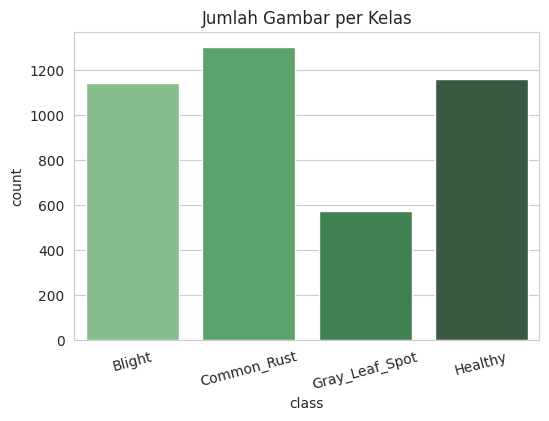

class
Blight            1146
Common_Rust       1306
Gray_Leaf_Spot     574
Healthy           1162
dtype: int64


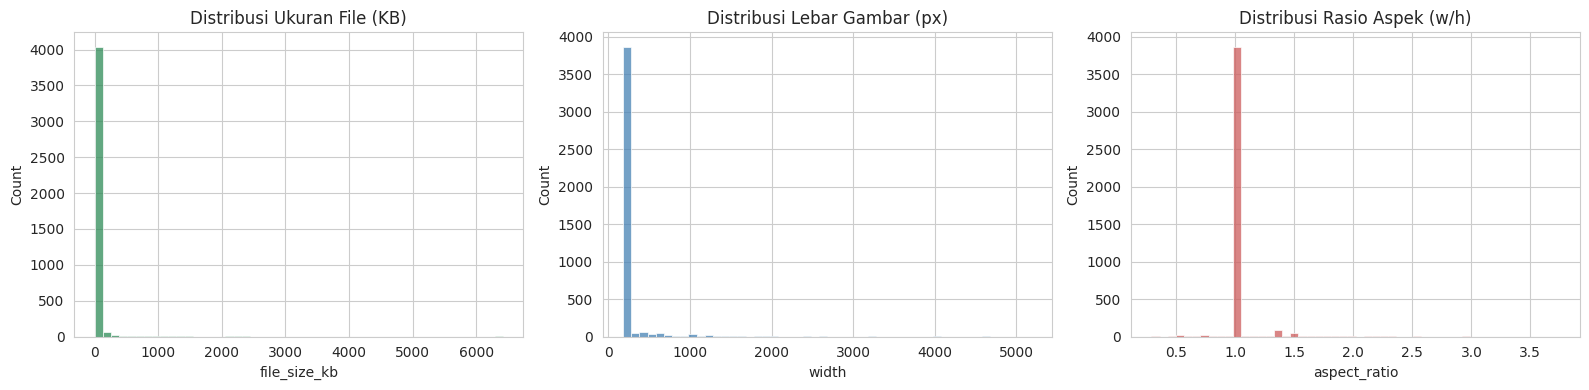

,file_size_kb,width,height,aspect_ratio
count,4188.000000,4188.000000,4188.000000,4188.000000
mean,39.915494,307.536533,297.906160,1.024146
std,227.460337,285.716933,253.138674,0.163395
min,3.783203,180.000000,116.000000,0.287854
25%,11.618164,256.000000,256.000000,1.000000
50%,13.691895,256.000000,256.000000,1.000000
75%,15.799805,256.000000,256.000000,1.000000
max,6419.989258,5184.000000,5184.000000,3.747899


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class', order=classes, palette='Greens_d')
plt.title('Jumlah Gambar per Kelas')
plt.xticks(rotation=15)
plt.show()

print(df.groupby('class').size())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['file_size_kb'], bins=50, ax=axes[0], color='seagreen')
axes[0].set_title('Distribusi Ukuran File (KB)')
sns.histplot(df['width'], bins=50, ax=axes[1], color='steelblue')
axes[1].set_title('Distribusi Lebar Gambar (px)')
sns.histplot(df['aspect_ratio'], bins=50, ax=axes[2], color='indianred')
axes[2].set_title('Distribusi Rasio Aspek (w/h)')
plt.tight_layout()
plt.show()

df[['file_size_kb', 'width', 'height', 'aspect_ratio']].describe()

# **5. Deteksi Duplikat Persis (MD5)**

Cell ini menghitung hash MD5 dari isi biner tiap file. Kalau dua file punya MD5 yang sama persis, itu tandanya kedua file itu identik byte-per-byte (benar-benar salinan yang sama, bukan cuma mirip). Hasilnya ditampilkan sebagai daftar file yang punya "kembaran".

In [ ]:
def md5_hash(filepath):
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

tqdm.pandas(desc="Menghitung MD5 hash")
df['md5'] = df['filepath'].progress_apply(md5_hash)

dup_exact = df[df.duplicated('md5', keep=False)].sort_values('md5')
print(f"Jumlah file yang merupakan duplikat persis: {len(dup_exact)}")
if len(dup_exact) > 0:
    display(dup_exact[['filepath', 'class', 'md5']].head(10))

Menghitung MD5 hash:   0%|          | 0/4188 [00:00<?, ?it/s]

Jumlah file yang merupakan duplikat persis: 4


,filepath,class,md5
63,/content/corn_dataset/data/Blight/Corn_Blight ...,Blight,43ba8a87d9053032195c7c59bc01f1fc
2735,/content/corn_dataset/data/Gray_Leaf_Spot/Corn...,Gray_Leaf_Spot,43ba8a87d9053032195c7c59bc01f1fc
865,/content/corn_dataset/data/Blight/Corn_Blight ...,Blight,a5c506de47aa579eb224f2c2c398fb7f
2993,/content/corn_dataset/data/Gray_Leaf_Spot/Corn...,Gray_Leaf_Spot,a5c506de47aa579eb224f2c2c398fb7f


# **6. Deteksi Duplikat Mirip (pHash)**

Beda dari MD5, cell ini pakai perceptual hash — bisa mengenali dua gambar sebagai "mirip secara visual" meskipun file-nya sudah di-crop/resize/kompres ulang (jadi MD5-nya beda, tapi isinya sebenarnya foto yang sama). Setiap pasangan gambar dalam kelas yang sama dibandingkan jarak hash-nya (hamming distance); kalau ≤ 5, dianggap mirip dan dicatat pasangannya.

In [ ]:
tqdm.pandas(desc="Menghitung perceptual hash")
df['phash'] = df['filepath'].progress_apply(lambda p: imagehash.phash(Image.open(p)))

near_dup_pairs = []
for class_name in classes:
    sub = df[df['class'] == class_name].reset_index()
    hashes = sub['phash'].values
    for i in range(len(hashes)):
        for j in range(i + 1, len(hashes)):
            dist = hashes[i] - hashes[j]
            if dist <= 5:
                near_dup_pairs.append({
                    'class': class_name,
                    'file_1': sub.loc[i, 'filepath'],
                    'file_2': sub.loc[j, 'filepath'],
                    'hamming_distance': dist,
                })

near_dup_df = pd.DataFrame(near_dup_pairs)
print(f"Jumlah pasangan near-duplicate ditemukan: {len(near_dup_df)}")
if len(near_dup_df) > 0:
    display(near_dup_df.sort_values('hamming_distance').head(10))

Menghitung perceptual hash:   0%|          | 0/4188 [00:00<?, ?it/s]

Jumlah pasangan near-duplicate ditemukan: 10


,class,file_1,file_2,hamming_distance
7,Healthy,/content/corn_dataset/data/Healthy/Corn_Health...,/content/corn_dataset/data/Healthy/Corn_Health...,0
5,Common_Rust,/content/corn_dataset/data/Common_Rust/Corn_Co...,/content/corn_dataset/data/Common_Rust/Corn_Co...,0
6,Common_Rust,/content/corn_dataset/data/Common_Rust/Corn_Co...,/content/corn_dataset/data/Common_Rust/Corn_Co...,2
4,Blight,/content/corn_dataset/data/Blight/Corn_Blight ...,/content/corn_dataset/data/Blight/Corn_Blight ...,2
3,Blight,/content/corn_dataset/data/Blight/Corn_Blight ...,/content/corn_dataset/data/Blight/Corn_Blight ...,4
2,Blight,/content/corn_dataset/data/Blight/Corn_Blight ...,/content/corn_dataset/data/Blight/Corn_Blight ...,4
1,Blight,/content/corn_dataset/data/Blight/Corn_Blight ...,/content/corn_dataset/data/Blight/Corn_Blight ...,4
0,Blight,/content/corn_dataset/data/Blight/Corn_Blight ...,/content/corn_dataset/data/Blight/Corn_Blight ...,4
8,Healthy,/content/corn_dataset/data/Healthy/Corn_Health...,/content/corn_dataset/data/Healthy/Corn_Health...,4
9,Healthy,/content/corn_dataset/data/Healthy/Corn_Health...,/content/corn_dataset/data/Healthy/Corn_Health...,4


# **7. Hitung Brightness & Sharpness**

Cell ini mengukur dua indikator kualitas gambar: brightness (rata-rata kecerahan piksel, untuk deteksi foto terlalu gelap/terang) dan sharpness (variansi Laplacian, untuk deteksi foto blur/tidak fokus — nilai rendah berarti gambarnya cenderung buram).

Menghitung brightness & sharpness:   0%|          | 0/4188 [00:00<?, ?it/s]

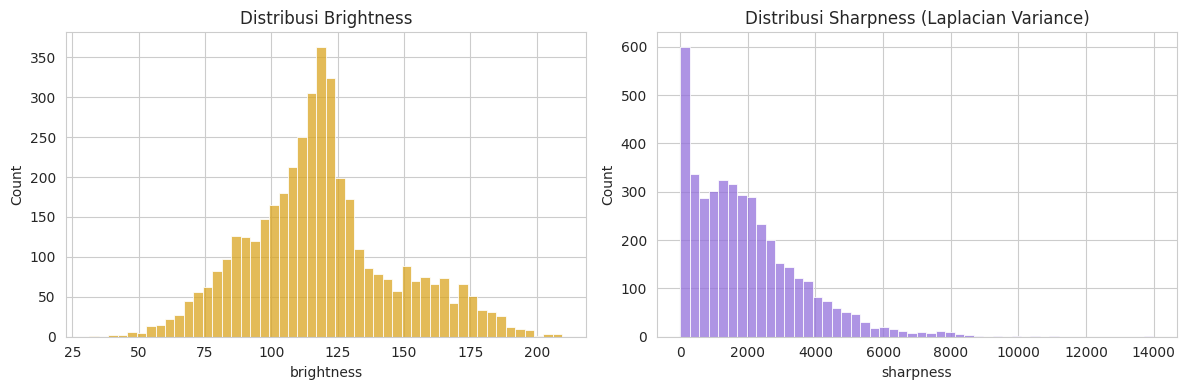

In [ ]:
def compute_quality_metrics(filepath):
    img = cv2.imread(filepath)
    if img is None:
        return pd.Series({'brightness': np.nan, 'sharpness': np.nan})
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = gray.mean()
    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
    return pd.Series({'brightness': brightness, 'sharpness': sharpness})

tqdm.pandas(desc="Menghitung brightness & sharpness")
quality_df = df['filepath'].progress_apply(compute_quality_metrics)
df = pd.concat([df, quality_df], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['brightness'], bins=50, ax=axes[0], color='goldenrod')
axes[0].set_title('Distribusi Brightness')
sns.histplot(df['sharpness'], bins=50, ax=axes[1], color='mediumpurple')
axes[1].set_title('Distribusi Sharpness (Laplacian Variance)')
plt.tight_layout()
plt.show()

# **8. Tandai Outlier (metode IQR, per kelas)**

Cell ini menandai gambar mana saja yang dianggap "outlier" berdasarkan tiga metrik (brightness, sharpness, aspect ratio), memakai metode statistik IQR: batasnya [Q1 - 1.5×IQR, Q3 + 1.5×IQR]. Dihitung per kelas (bukan gabungan semua kelas), karena karakteristik visual tiap penyakit bisa berbeda secara wajar. Di akhir, ditampilkan ringkasan jumlah temuan per kategori.

In [ ]:
def flag_outliers_iqr(group, col):
    q1, q3 = group[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (group[col] < lower) | (group[col] > upper)

df['outlier_brightness'] = df.groupby('class', group_keys=False).apply(lambda g: flag_outliers_iqr(g, 'brightness'))
df['outlier_sharpness'] = df.groupby('class', group_keys=False).apply(lambda g: flag_outliers_iqr(g, 'sharpness'))
df['outlier_dimension'] = df.groupby('class', group_keys=False).apply(lambda g: flag_outliers_iqr(g, 'aspect_ratio'))

df['is_duplicate'] = df['md5'].duplicated(keep='first')
df['is_outlier'] = df[['outlier_brightness', 'outlier_sharpness', 'outlier_dimension']].any(axis=1)

print("Ringkasan temuan:")
print(f"- Gambar korup           : {len(corrupted_files)}")
print(f"- Duplikat persis        : {df['is_duplicate'].sum()}")
print(f"- Outlier brightness     : {df['outlier_brightness'].sum()}")
print(f"- Outlier sharpness      : {df['outlier_sharpness'].sum()}")
print(f"- Outlier dimensi/rasio  : {df['outlier_dimension'].sum()}")
print(f"- Total ditandai (union) : {(df['is_duplicate'] | df['is_outlier']).sum()}")

Ringkasan temuan:
- Gambar korup           : 0
- Duplikat persis        : 2
- Outlier brightness     : 122
- Outlier sharpness      : 170
- Outlier dimensi/rasio  : 329
- Total ditandai (union) : 556


/tmp/ipykernel_808/1156465177.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['outlier_brightness'] = df.groupby('class', group_keys=False).apply(lambda g: flag_outliers_iqr(g, 'brightness'))
/tmp/ipykernel_808/1156465177.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['outlier_sharpness'] = df.groupby('class', group_keys=False).apply(lambda g: flag_outliers_iqr(g, 'sharpness'))
/tmp/ipykernel

# **9. Inspeksi Visual Outlier**

Sebelum benar-benar menghapus, cell ini menampilkan contoh gambar dari tiap kategori outlier (9 gambar acak per kategori) supaya kamu bisa cek langsung dengan mata — jangan-jangan ada gambar yang "outlier" secara statistik tapi sebenarnya tetap valid dan penting untuk training (misalnya kondisi pencahayaan ekstrem yang memang nyata terjadi di lapangan).

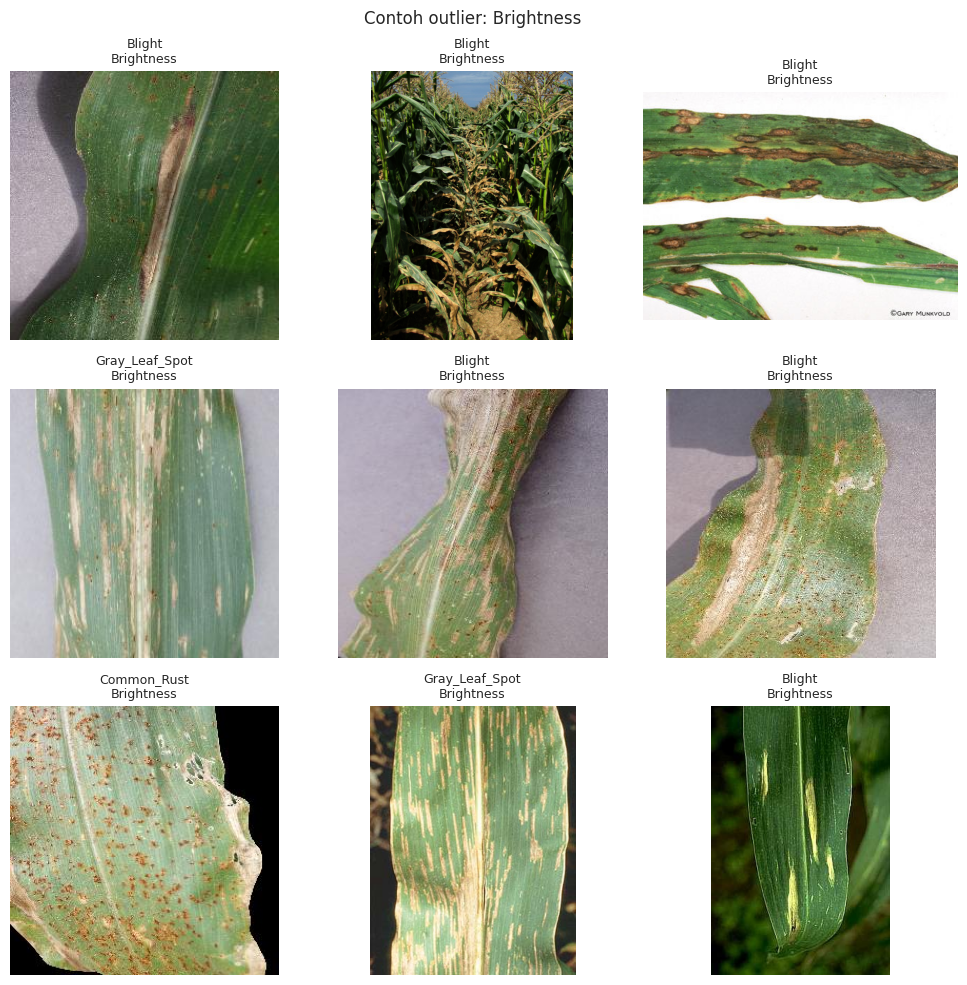

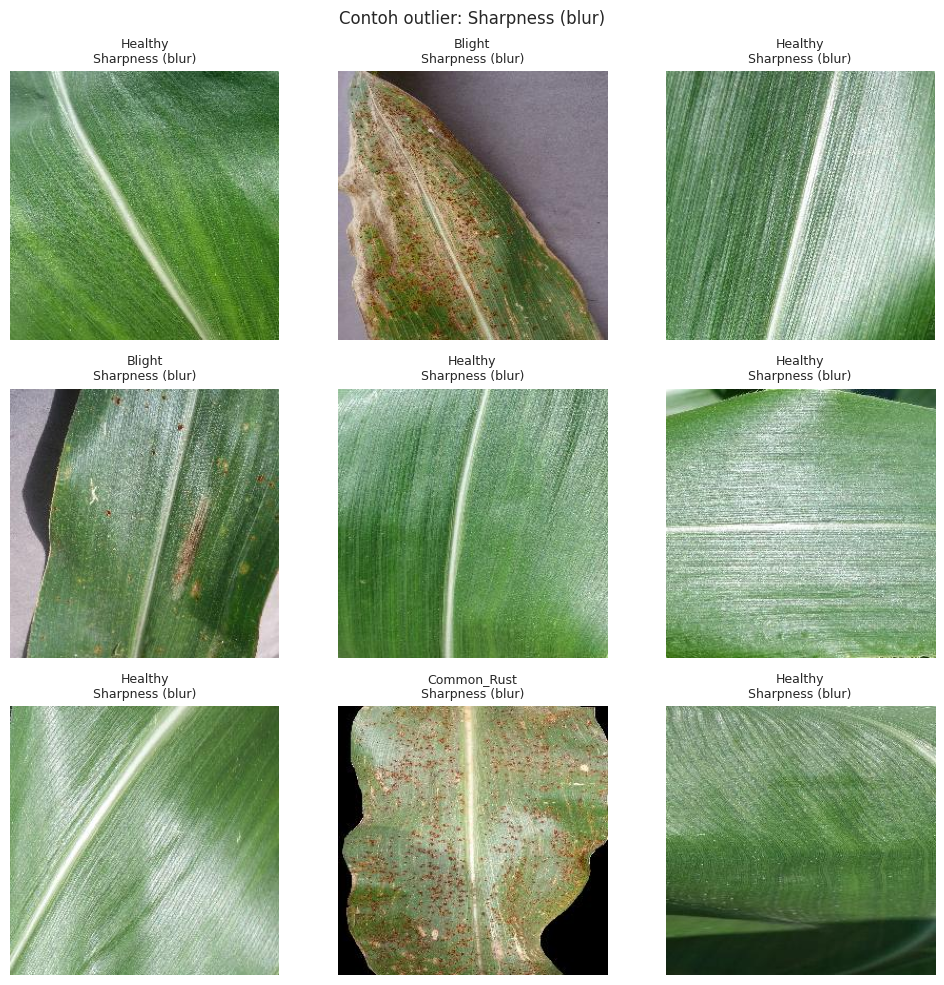

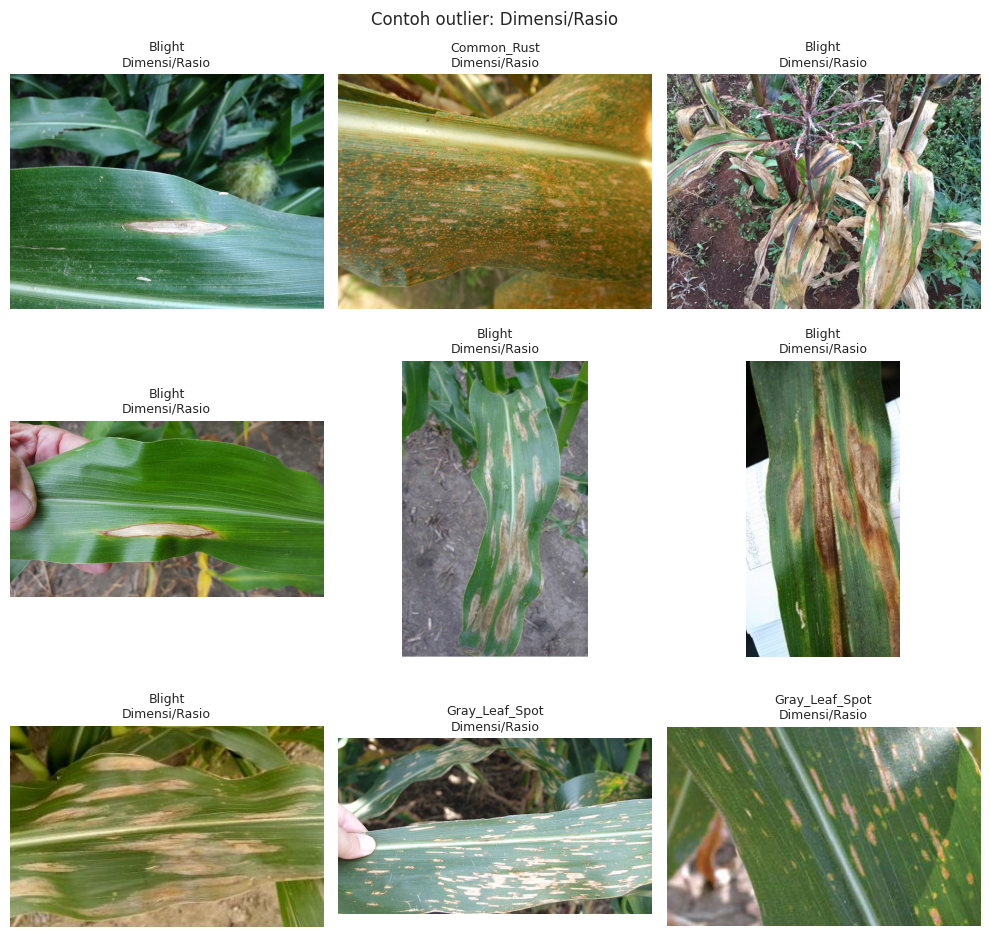

In [ ]:
def show_outlier_samples(flag_col, title, n=9):
    sample = df[df[flag_col] == True].sample(min(n, df[flag_col].sum()), random_state=42) if df[flag_col].sum() > 0 else df.iloc[0:0]
    if len(sample) == 0:
        print(f"Tidak ada outlier untuk kategori: {title}")
        return
    plt.figure(figsize=(10, 10))
    for i, (_, row) in enumerate(sample.iterrows()):
        ax = plt.subplot(3, 3, i + 1)
        img = Image.open(row['filepath'])
        plt.imshow(img)
        plt.title(f"{row['class']}\n{title}", fontsize=9)
        plt.axis('off')
    plt.suptitle(f"Contoh outlier: {title}")
    plt.tight_layout()
    plt.show()

show_outlier_samples('outlier_brightness', 'Brightness')
show_outlier_samples('outlier_sharpness', 'Sharpness (blur)')
show_outlier_samples('outlier_dimension', 'Dimensi/Rasio')

# **10. Bersihkan & Simpan Dataset**

Ini eksekusi cleaning-nya: gambar yang tidak ditandai duplikat maupun outlier disalin ke folder baru corn_dataset_clean/ dengan struktur folder per kelas yang sama seperti aslinya. Di akhir, ditampilkan perbandingan jumlah gambar sebelum vs sesudah dibersihkan, per kelas.

In [ ]:
clean_dir = pathlib.Path('/content/corn_dataset_clean')
if clean_dir.exists():
    shutil.rmtree(clean_dir)

df_clean = df[(~df['is_duplicate']) & (~df['is_outlier'])].copy()

for class_name in classes:
    (clean_dir / class_name).mkdir(parents=True, exist_ok=True)

for _, row in tqdm(df_clean.iterrows(), total=len(df_clean), desc="Menyalin gambar bersih"):
    src = pathlib.Path(row['filepath'])
    dst = clean_dir / row['class'] / src.name
    shutil.copy2(src, dst)

print(f"Total gambar sebelum dibersihkan : {len(df) + len(corrupted_files)}")
print(f"Total gambar setelah dibersihkan : {len(df_clean)}")
print("\nJumlah per kelas setelah dibersihkan:")
print(df_clean.groupby('class').size())

Menyalin gambar bersih:   0%|          | 0/3632 [00:00<?, ?it/s]

Total gambar sebelum dibersihkan : 4188
Total gambar setelah dibersihkan : 3632

Jumlah per kelas setelah dibersihkan:
class
Blight             925
Common_Rust       1163
Gray_Leaf_Spot     476
Healthy           1068
dtype: int64


# **11. Zip & Download Dataset Bersih**

Cell terakhir: seluruh folder corn_dataset_clean/ dikompres jadi satu file .zip, lalu langsung memicu dialog download di browser supaya kamu bisa simpan hasilnya dan pakai di notebook training berikutnya.

In [ ]:
clean_zip_path = '/content/corn_dataset_clean.zip'
shutil.make_archive('/content/corn_dataset_clean', 'zip', clean_dir)

from google.colab import files
files.download(clean_zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>